In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#1. Load data
df = pd.read_csv('league_match_data.csv', on_bad_lines='skip')
print(df.head())

         match_id    region champion_name  team_id   win     role  kills  \
0  NA1_5542864022  americas          Gwen      100  True      TOP      7   
1  NA1_5542864022  americas      Pantheon      100  True   JUNGLE     13   
2  NA1_5542864022  americas         Annie      100  True   MIDDLE      1   
3  NA1_5542864022  americas          Jhin      100  True   BOTTOM     13   
4  NA1_5542864022  americas          Bard      100  True  UTILITY      1   

   deaths  assists  damage_to_champs  gold_earned  
0       5       10             21773        12723  
1       0       12             36586        14663  
2       3       10             21132        10491  
3       4        8             26946        16300  
4       0       25             17461         9025  


In [3]:
#2. data statistics
print('Data Info:')
print(df.info())
print(df.describe())
print('Missing Values:')
print(df.isna().sum()/len(df))
df = df.dropna(subset=['role'])
df = df[df['role']!= '']
print('Missing Values after dropping NA:')
print(df.isna().sum())

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28396 entries, 0 to 28395
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   match_id          28396 non-null  object
 1   region            28396 non-null  object
 2   champion_name     28396 non-null  object
 3   team_id           28396 non-null  int64 
 4   win               28396 non-null  bool  
 5   role              25620 non-null  object
 6   kills             28396 non-null  int64 
 7   deaths            28396 non-null  int64 
 8   assists           28396 non-null  int64 
 9   damage_to_champs  28396 non-null  int64 
 10  gold_earned       28396 non-null  int64 
dtypes: bool(1), int64(6), object(4)
memory usage: 2.2+ MB
None
           team_id         kills        deaths       assists  \
count  28396.00000  28396.000000  28396.000000  28396.000000   
mean     150.00000      5.534653      5.555677      7.993626   
std       50.00088      4.

In [4]:
#3. EDA
print(df['champion_name'].value_counts())
print(df['role'].value_counts())

df['role'] = df['role'].replace('UTILITY', 'SUPPORT')
print(df['role'].value_counts())

champion_name
Ezreal         797
Jayce          590
Anivia         567
Karma          522
Ambessa        512
              ... 
TahmKench       17
Illaoi          17
Rammus          16
Warwick         12
Mordekaiser     11
Name: count, Length: 172, dtype: int64
role
TOP        5124
JUNGLE     5124
MIDDLE     5124
BOTTOM     5124
UTILITY    5124
Name: count, dtype: int64
role
TOP        5124
JUNGLE     5124
MIDDLE     5124
BOTTOM     5124
SUPPORT    5124
Name: count, dtype: int64


In [5]:
#Check if gold/damage correlation differs by region
for region in df['region'].unique():
    region_df = df[df['region'] == region]
    corr = region_df['gold_earned'].corr(region_df['damage_to_champs'])
    print(f"Region: {region} | Gold-Damage Correlation: {corr:.3f}")


Region: americas | Gold-Damage Correlation: 0.857
Region: europe | Gold-Damage Correlation: 0.869
Region: asia | Gold-Damage Correlation: 0.875


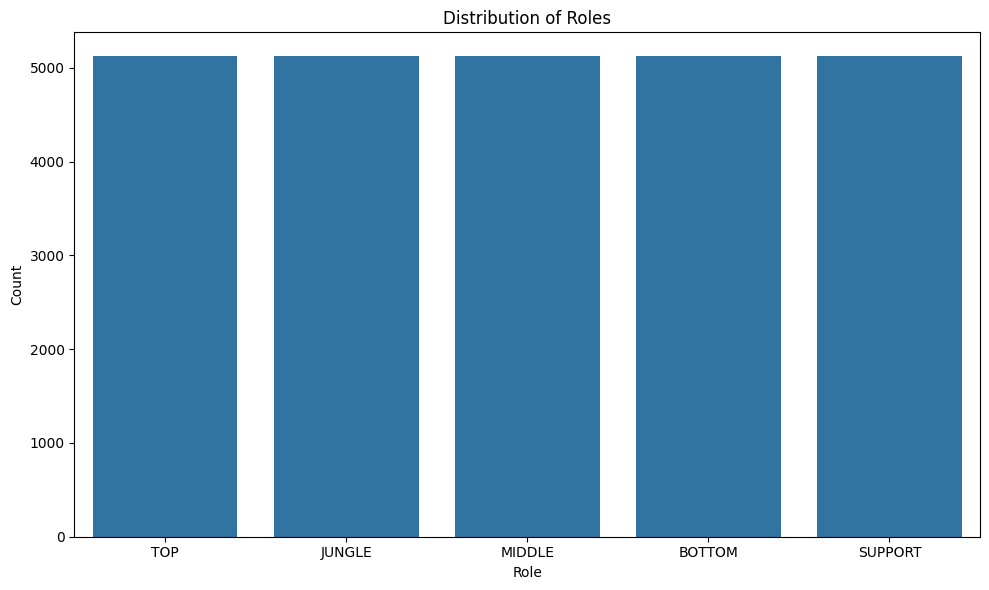

In [6]:
#4. Visualizations
# Role Distribution
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='role', order=df['role'].value_counts().index)
plt.title('Distribution of Roles')
plt.xlabel('Role')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


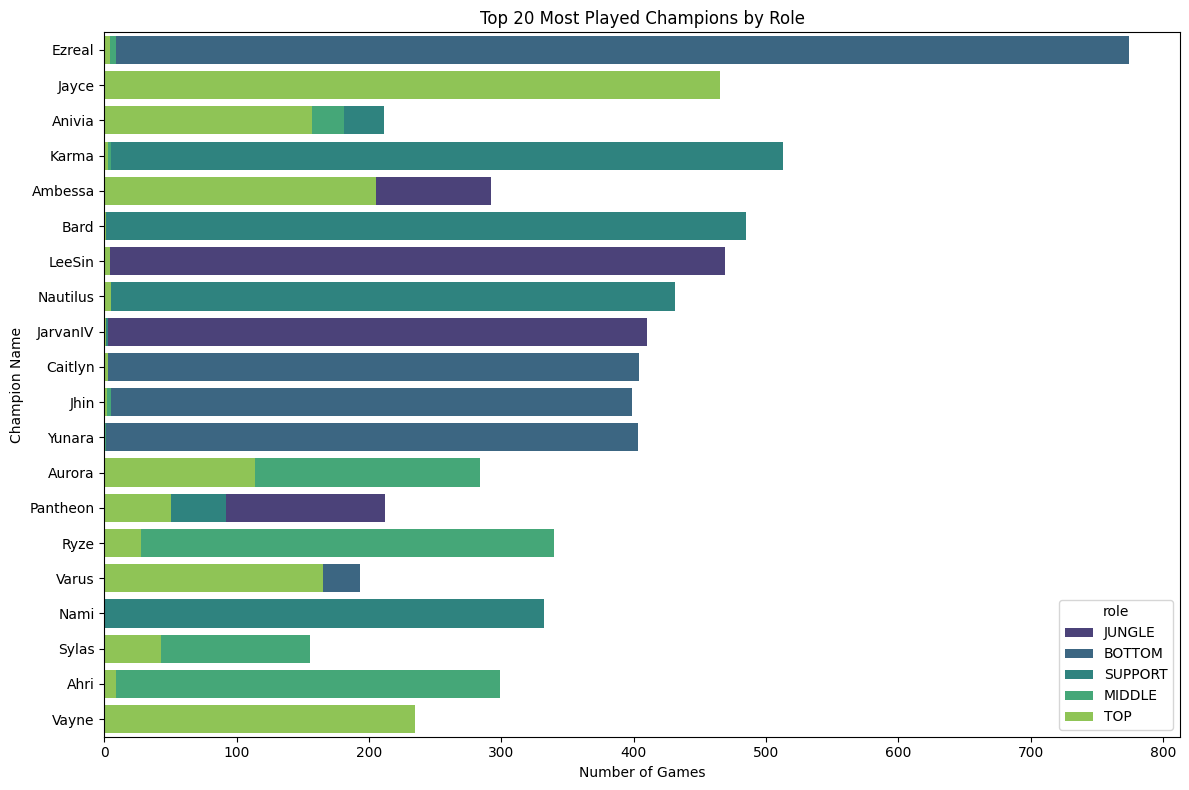

In [7]:
#Top 20 Most Played Champions
top_20_names = df['champion_name'].value_counts().nlargest(20).index

# 2. Filter original df to only contain rows for these top 20 champions
top_df = df[df['champion_name'].isin(top_20_names)]

# 3. Plot using countplot with the filtered data
plt.figure(figsize=(12, 8)) # Increased size for better visibility
sns.countplot(
    data=top_df, 
    y='champion_name', 
    order=top_20_names, # Ensures consistent ordering
    hue='role',
    palette='viridis',
    dodge=False
)
plt.title('Top 20 Most Played Champions by Role')
plt.xlabel('Number of Games')
plt.ylabel('Champion Name')
plt.tight_layout() # Adjusts layout to fit labels
plt.show()

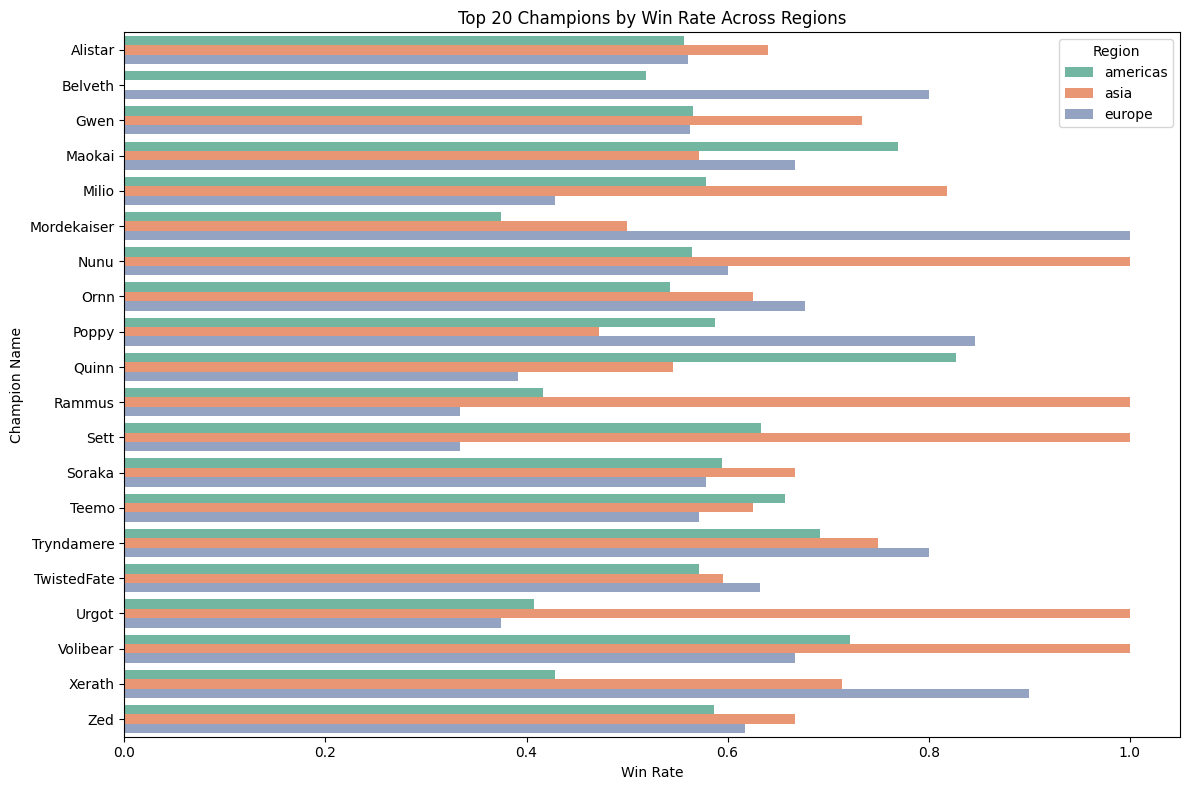

In [8]:
#Top champions by region
champion_region_win_rates = df.groupby(['champion_name', 'region'])['win'].mean().reset_index()
top_champions = champion_region_win_rates.groupby('champion_name')['win'].mean().sort_values(ascending=False).head(20).index
top_champion_region_win_rates = champion_region_win_rates[champion_region_win_rates['champion_name'].isin(top_champions)]
plt.figure(figsize=(12, 8))
sns.barplot(x='win', y='champion_name', hue='region', data=top_champion_region_win_rates, palette='Set2')
plt.title('Top 20 Champions by Win Rate Across Regions')
plt.xlabel('Win Rate')
plt.ylabel('Champion Name')
plt.legend(title='Region')
plt.tight_layout()
plt.show()

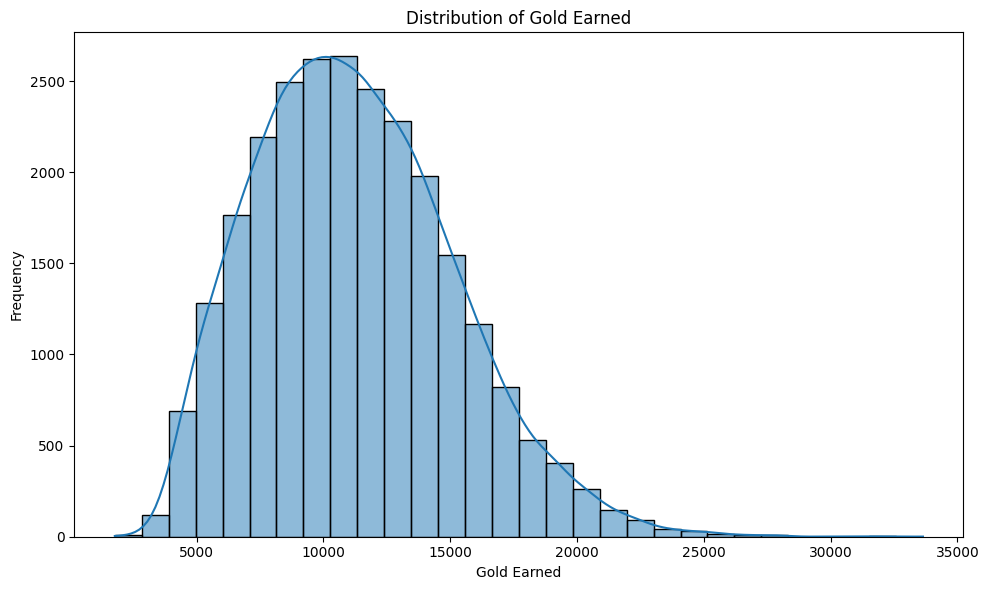

In [9]:
# Gold Earned Distribution
plt.figure(figsize=(10,6))
sns.histplot(df['gold_earned'], bins=30, kde=True)
plt.title('Distribution of Gold Earned')
plt.xlabel('Gold Earned')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

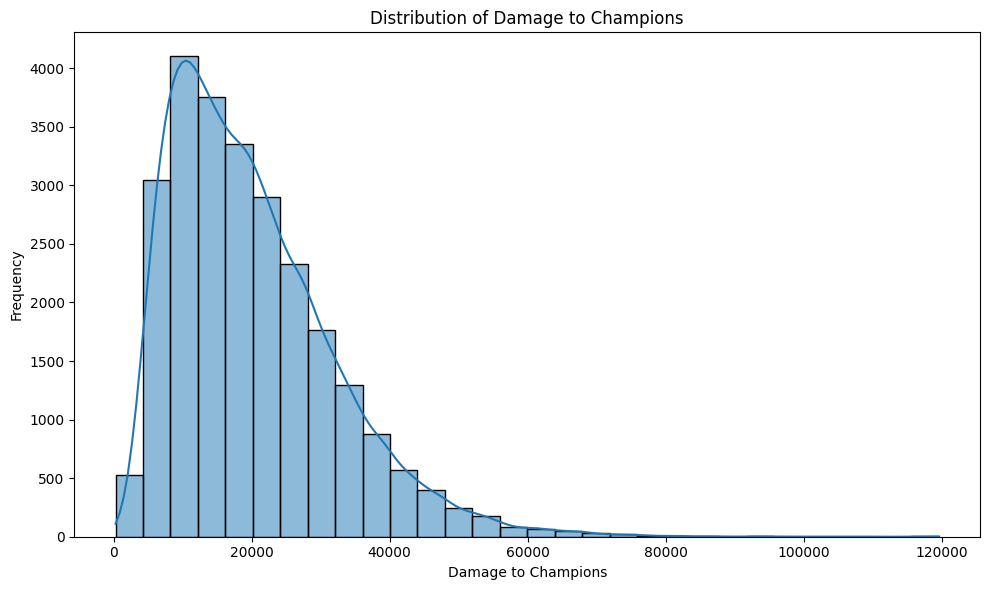

In [10]:
# Damage to Champions Distribution
plt.figure(figsize=(10,6))
sns.histplot(df['damage_to_champs'], bins=30, kde=True)
plt.title('Distribution of Damage to Champions')
plt.xlabel('Damage to Champions')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

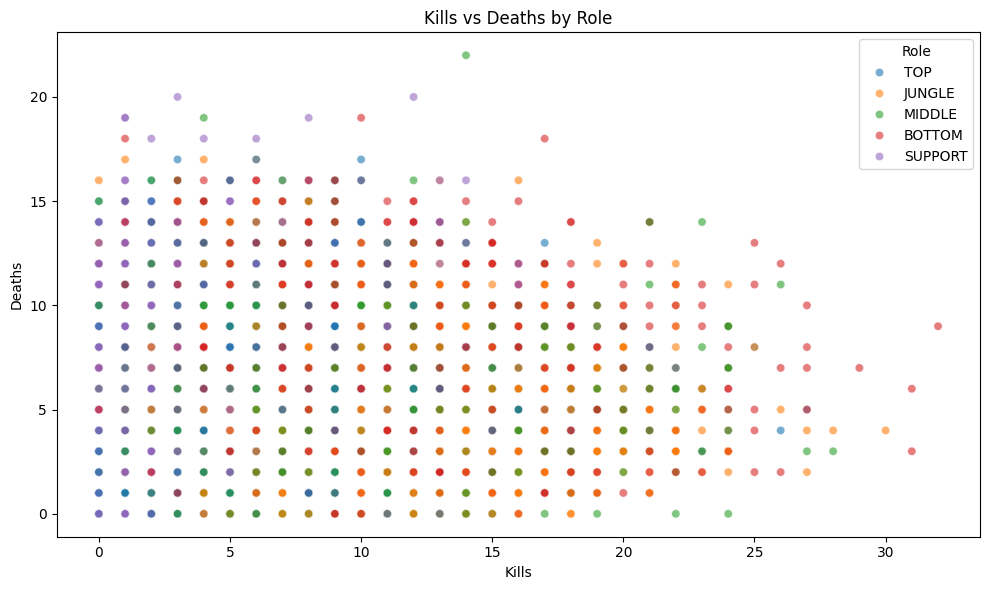

In [11]:
# Kills vs Deaths
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='kills', y='deaths', hue='role', alpha=0.6)
plt.title('Kills vs Deaths by Role')
plt.xlabel('Kills')
plt.ylabel('Deaths')
plt.legend(title='Role')
plt.tight_layout()
plt.show()

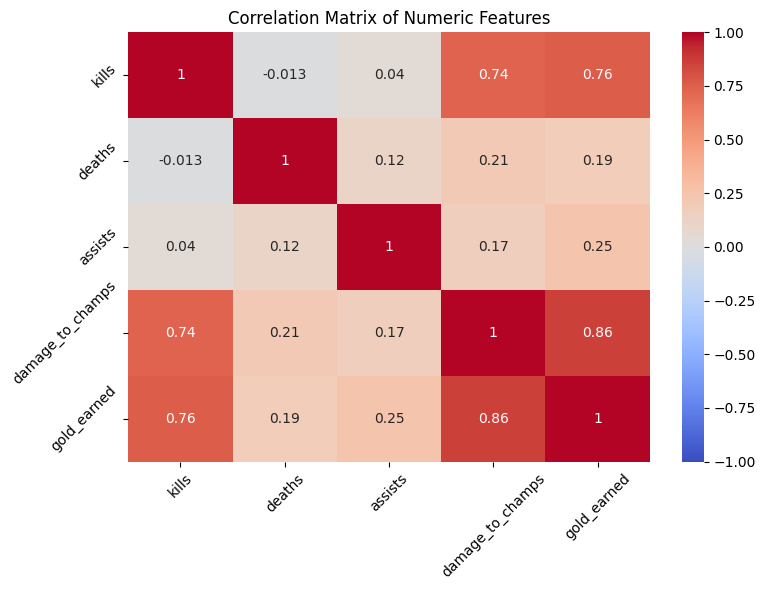

In [12]:
#5. Correlation Analysis
numeric_cols = ['kills', 'deaths', 'assists', 'damage_to_champs', 'gold_earned']
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

In [13]:
#Save cleaned data
df.to_csv('cleaned_league_match_data.csv', index=False)
df.groupby('role')['champion_name'].unique().to_json('champion_roles.json')